# 6.1 Introduction to Neural Network

In [2]:
using CairoMakie
using Zygote

As was seen, in the previous notebook, polynomials might not be flexible enough to approximate any complex functions.  Furthermore, if you use polynomials, it gets very expensive for function of many variables.  Neural Network has proven to be a framework that is able to approximate any function, no matter how complex.  There are theories that show that Neural Network is a Universal Function Approximator, that is it can approximate any function.


Neural Network are just complex functions that can take inputs, $\vec{x}$, and produces many outputs $\vec{NN}$. In general,  $\vec{NN}$ and $\vec{x}$ are vectors.  Neural Networks also have parameters that you can tune to make $\vec{NN}$ fit any function.  There are theories that show that you can approximate any function with $\vec{NN}$.  

In its most general form, a Neural Network can be written as $\vec{NN}(\vec{x};\mathbf{W},\vec{b})$ where

$\mathbf{W}$ are called weights and it is a matrix and
$\vec{b}$ is a vector called biases



---

# One input one output

We will first look at the most simple case of a Neural Network with one input and one output.  In its most simplest form, the $NN(x;W,b)$ is expressed as  nonlinear functions of $Wx+b$, where $W$  and $b$ are parameters that can be tuned to fit a function

$NN(x;W,b)=\sigma(Wx+b)$

where $\sigma$ are called activation function. Some examples of $\sigma(s)$

$\sigma(s)=s$: Identity

$\sigma(s)=\frac{1}{1+e^{-s}}$: Sigmoid

$\sigma(s)=\frac{e^{s}-e^{-s}}{e^{s}+e^{-s}}$: Tanh

There are many more $\sigma$ that have been used.  One can find them on the internet. (see for example https://en.wikipedia.org/wiki/Activation_function).


Let's plot the functions and see how they look like





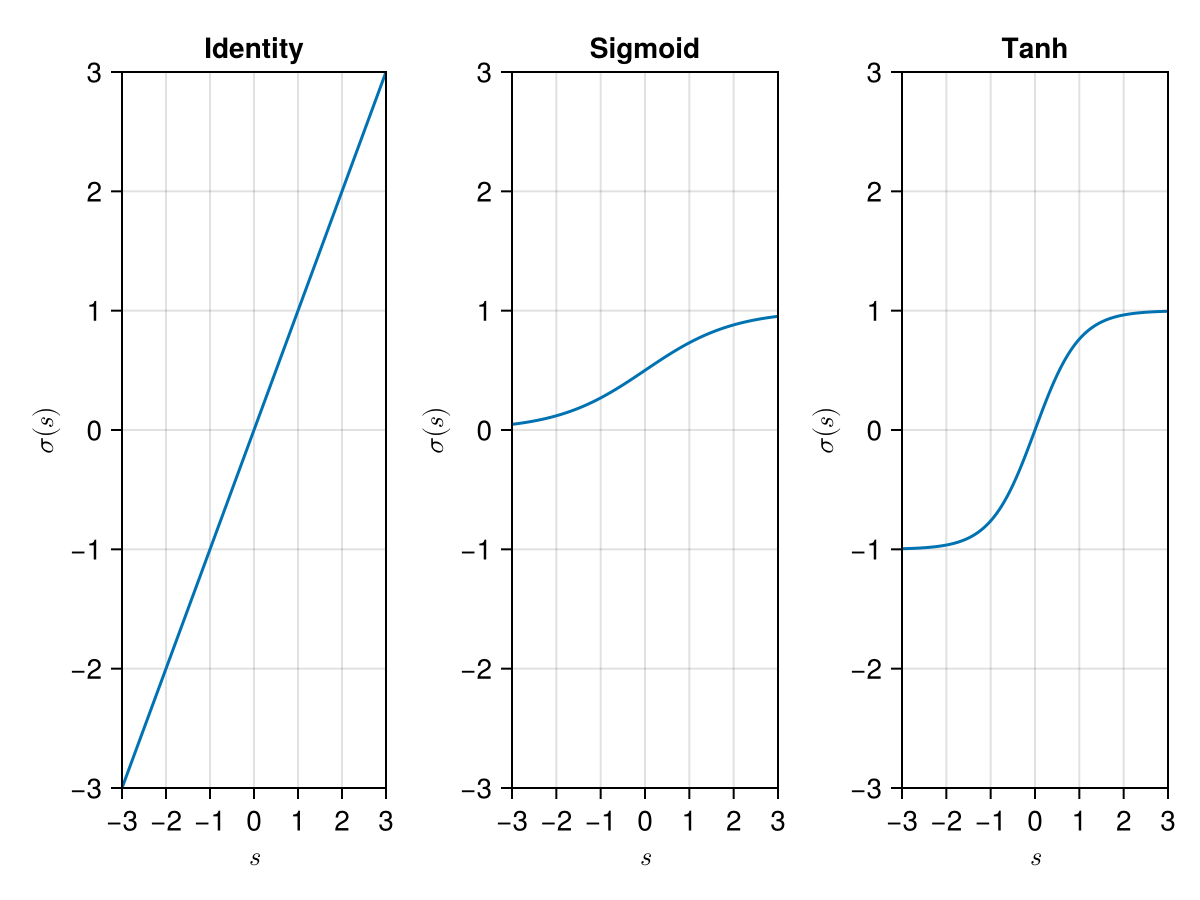

In [4]:
xplot=-3:0.01:3
function sigmoid(s)
    return 1.0 / (1.0 + exp(-s))
end

fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"s", ylabel = L"\sigma(s)",limits=(-3,3,-3.0,3.0),title="Identity")
lines!(ax,xplot,xplot)


ax = Axis(fig[1, 2], xlabel = L"s", ylabel = L"\sigma(s)",limits=(-3,3,-3.0,3.0),title="Sigmoid")
lines!(ax,xplot,sigmoid.(xplot))

ax = Axis(fig[1, 3], xlabel = L"s", ylabel = L"\sigma(s)",limits=(-3,3,-3.0,3.0),title="Tanh")
lines!(ax,xplot,tanh.(xplot))

save("../figures/ActivationFunction.svg",fig)

fig

This Neural Network 

$NN(x)=Wx+b$


can visually be represented as 

![Alt text for screen readers](../figures/03p03Fig01.svg)

(this figure was made using https://alexlenail.me/NN-SVG/)

* The left circle is the input $x$ 
* the right circle is the output $NN(x)$, or I will sometimes call $y(x)$. 
* The line between the two circles can be though of as the operation $\sigma(Wx+b)$, where $\sigma()$ is a nonlinear function. 

There is one node representing the input and one node representing the output.  For this Neural Network, $\sigma(s)=s$ and there are two parameters, $W$ and $b$ that you can change in order to change the Neural Network.  We will set $W=2$ and $b=1$ and plot $NN(x;W,b)$  to see how it looks like.

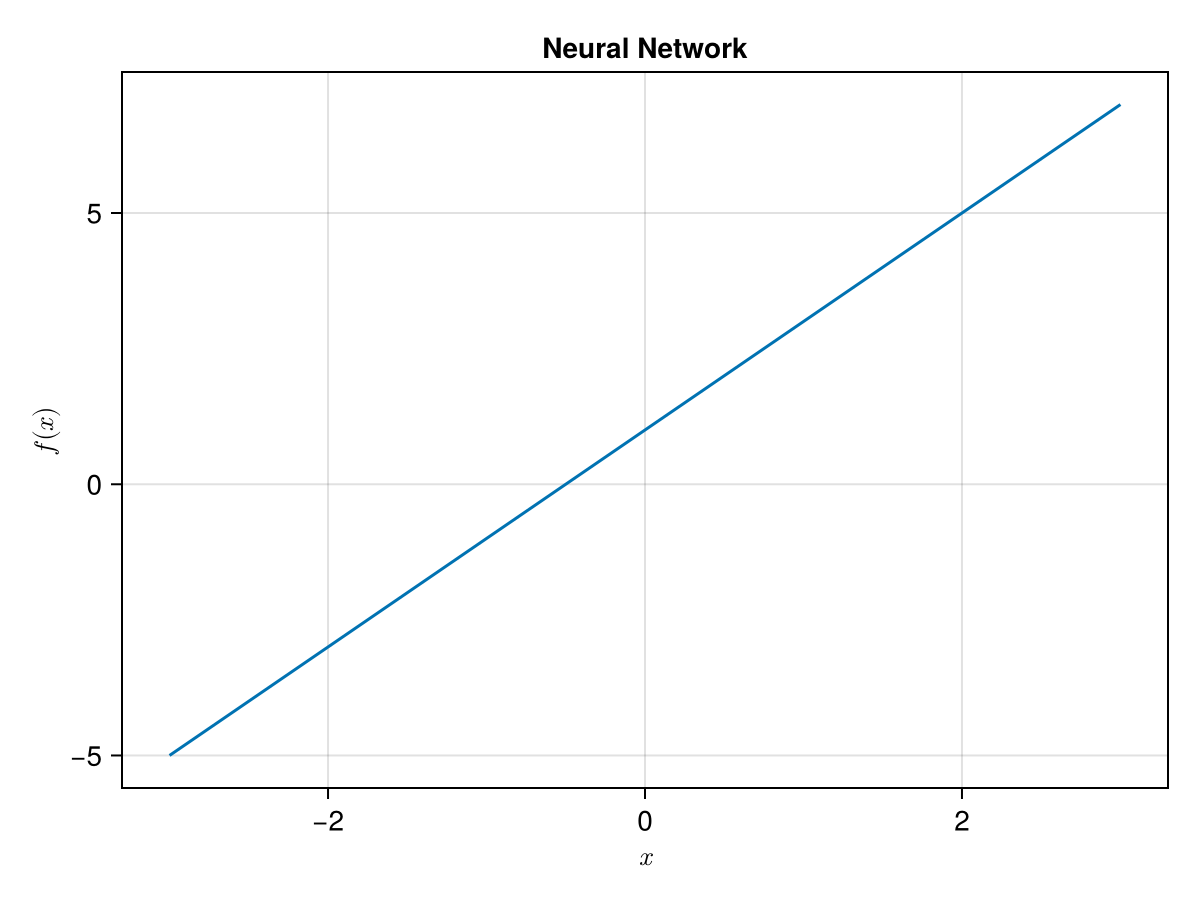

In [5]:
xplot=Array(-3:0.01:3)
W=2
b=1
function NN01(x,W,b)
    return W*x+b
end

fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)",title="Neural Network")
lines!(ax,xplot,NN01.(xplot,W,b))

fig


<u>Exercise Ex01:</u> Change the values of $W$ and $b$ and comment on how they change $f(x)$.

This Neural Network is not very exciting.   It is just a linear function.   One can add nonlinearity by changing $\sigma$ to a more complex $\tanh()$ function.

$NN(x)=\tanh(Wx+b)$

For this Neural Network, there are two parameters, $W$ and $b$ that you can change in order to change the Neural Network.  The graph below shows how the Neural network looks like for $W=1$ and $b=0$.

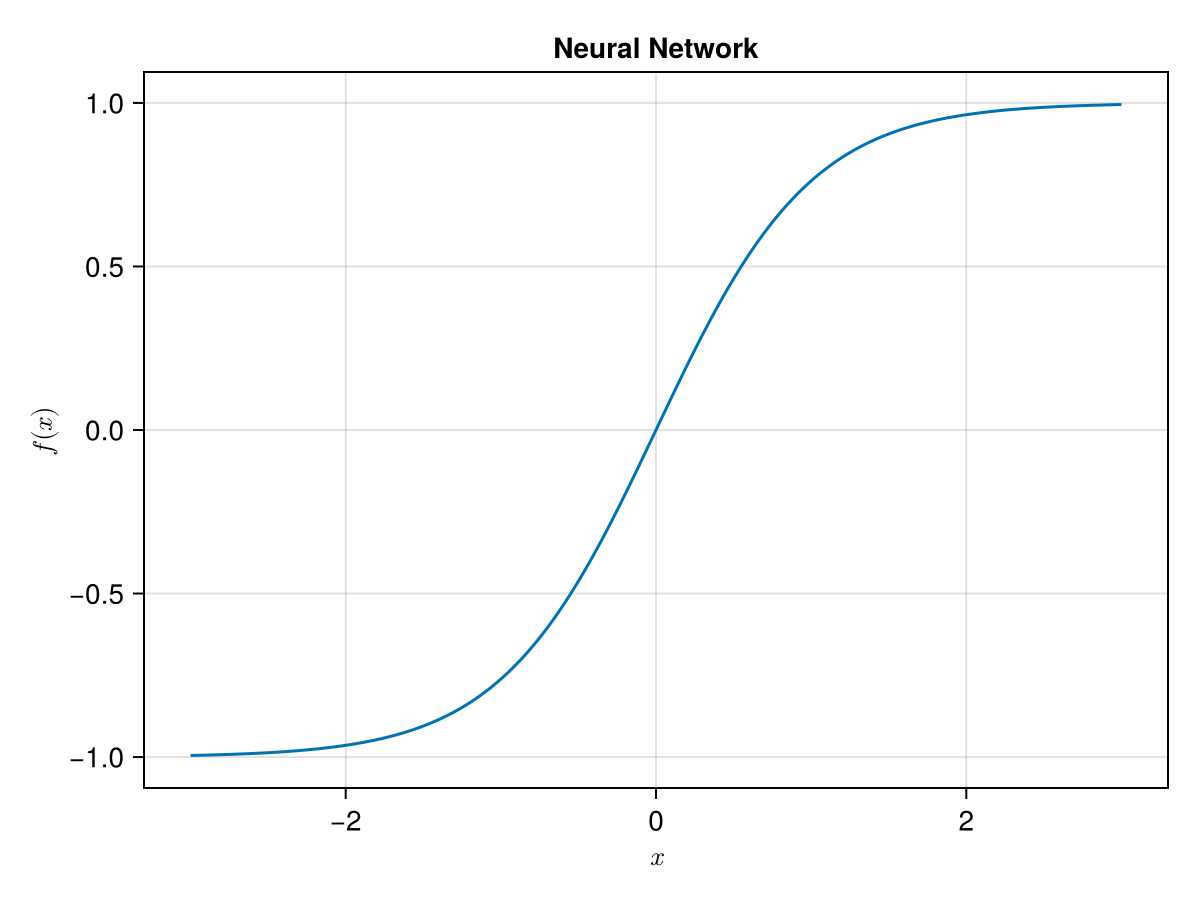

In [6]:
xplot=Array(-3:0.01:3)
W=1
b=0
function NN02(x,W,b)
    return tanh(W*x+b)
end

fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)",title="Neural Network")
lines!(ax,xplot,NN02.(xplot,W,b))

fig


<u>Exercise Ex02:</u> Change $W$ and $b$ and comment on how they change $f(x)$.

Usually, researchers use $NN$ to try and model some data.  We will generate some fictitious data and see if we can get a good model for the Neural Network  $NN(x;W,b)$ shown above.

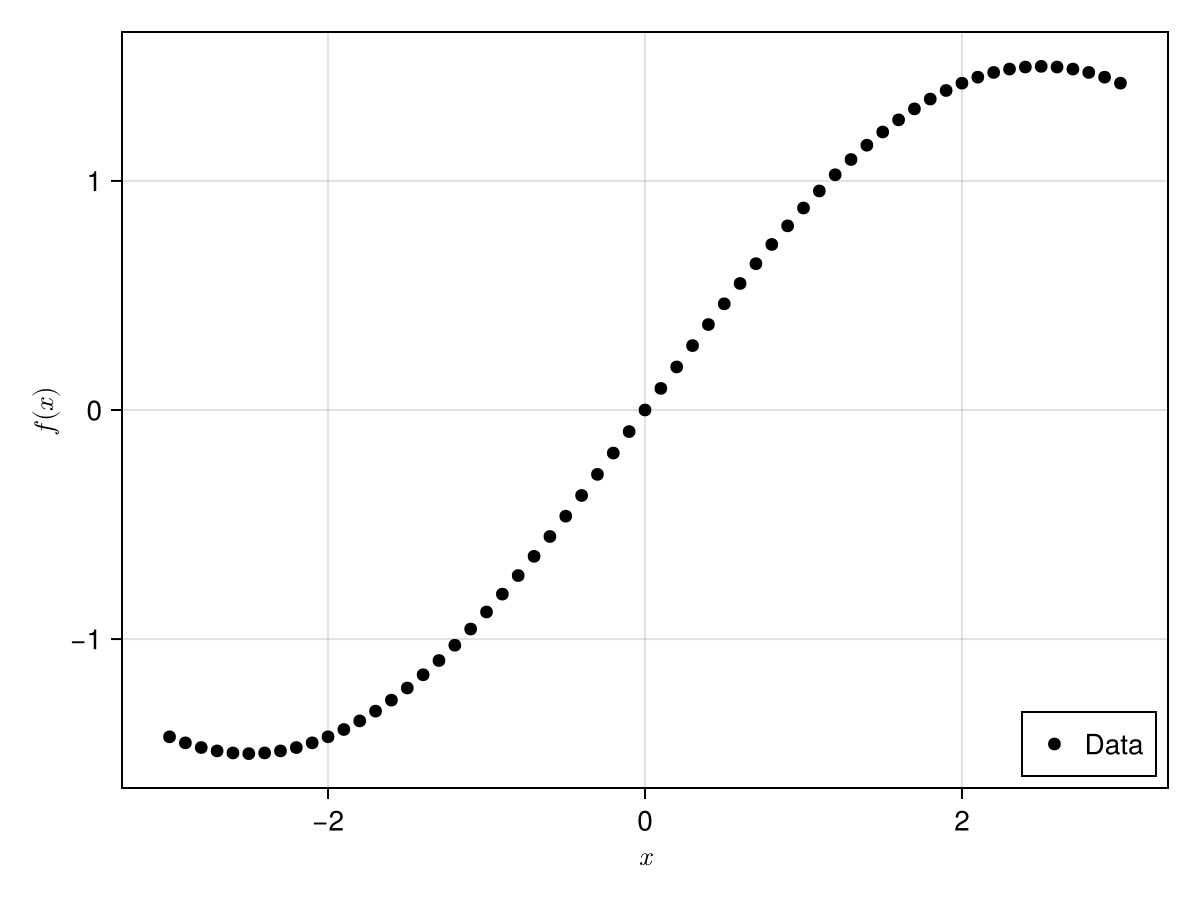

In [7]:
xplot=Array(-3:0.01:3)
xdata=Array(-3:0.1:3)
W=1
b=0.1
function NN02(x,W,b)
    return tanh(W*x+b)
end

fig = Figure(backgroundcolor = :transparent)
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)",backgroundcolor = :transparent)
#lines!(ax,xplot,NN02.(xplot,W,b);label="NN model",color=:blue,linewidth=5)
scatter!(ax,xdata,1.5*sin.(π*xdata/5.0);color=:black,label="Data") #fictitious data

save("../figures/06p01IntroductionToNeuralNetwork01.png",fig)

axislegend(ax,  position = :rb,orientation = :vertical)
fig

<u>Exercise Ex03:</u> Change $W$ and $b$ and see if you can make $NN$ a closer match to the black dots (data).  Can you get a good match with the data for this Neural Network?

---

**Class Demo 01** : Write a Julia program to optimise a one input, one output, Neural Network to fit the data in "Data01.csv"


---

---

**Class Demo 02** : See if you can use the same model to fit the data in "Data02.csv"


---

---

# Hidden layers
To model more complex function you can have Neural Networks with multiple hidden layers.  These hidden layers makes the $NN$ more flexible and able to approximate more complex functions.  The form of each of the  hidden layers are expressed in the form 

$\sigma(\mathbf{W}\vec{x}+\vec{b})$


This Neural Network can be visualised below.  There is one node representing the input, output and hidden layers.

![Alt text for screen readers](../figures/03p03Fig02.svg)

(this figure was made using https://alexlenail.me/NN-SVG/)

The input to the hidden layer, the left most line represent $h=\tanh(Wx+b)$, then from the hidden to the output layer, you have $W_2h+b_2$.  Hence the functional form of this Neural network can be written as


$NN(x)=W_2\tanh(W_1x+b_1)+b_2$.

For this Neural Network, there are four parameters, $W_1$, $W_2$, $b_1$ and $b_2$ that you can change in order to change the shape of the Neural Network.

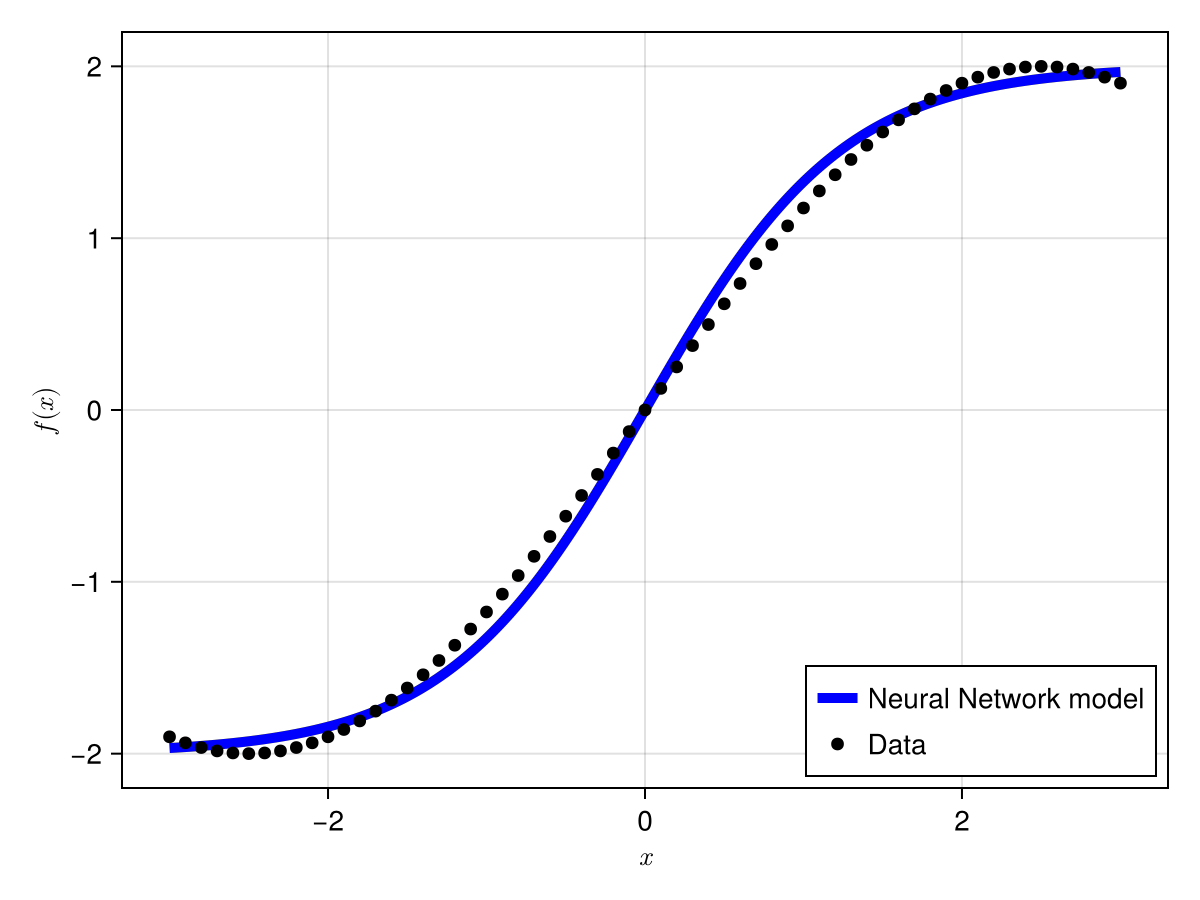

In [8]:
xplot=Array(-3:0.01:3)
xdata=Array(-3:0.1:3)

W=[0.8,2]
b=[0,0]

function NN03(x,W,b)
    return W[2]*tanh.(W[1]*x.+b[1]).+b[2]
end

fig = Figure(backgroundcolor=:transparent)
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)",backgroundcolor=:transparent)
lines!(ax,xplot,NN03(xplot,W,b);color=:blue,linewidth=5,label="Neural Network model")
scatter!(ax,xdata,2*sin.(π*xdata/5.0);color=:black,label="Data") #fictitious data
#save("../figures/06p01IntroductionToNeuralNetwork02.png",fig)
axislegend(ax,  position = :rb,orientation = :vertical)

fig

<u>Exercise 03:</u> Change $W_1$, $W_2$, $b_1$ and $b_2$ and comment on how they change $f(x)$.  Can you find a set of parameters so that the Neural Network makes a good approximation of the data?

---

#### Using optimisers to tune a Neural Network

As you can see from the exercise above, it is very tedious to find values of the $W$ s and $b$ s manually.....and you only have 4 parameters to tune!  Real Neural network have thousands or millions of parameters!  Let's see how you can use the optimisers introduced in previous notebooks to find the optimum set of $W$ s and $b$ s  that will give the best possible match to your data.

Suppose now you want to approximate a function $g(x)=2\sin(\pi  x/5)$ with a Neural Network. How would you do that?  Let's plot $g(x)$ and the Neural Network to see how they look like.  For the example below, we will start with $\mathbf{W}=\begin{Bmatrix} 1\\1\end{Bmatrix}$ and $\mathbf{b}=\begin{Bmatrix} 0\\0\end{Bmatrix}$.

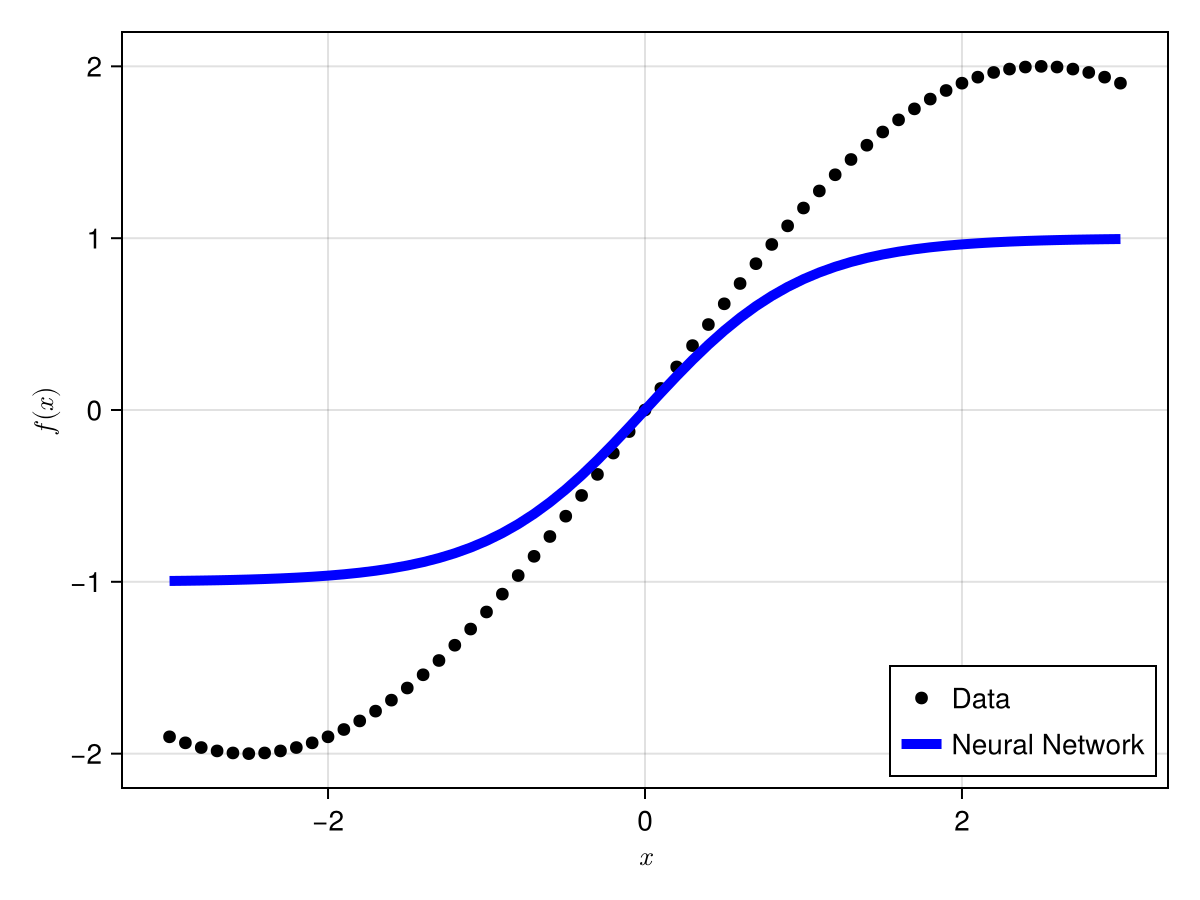

In [26]:
g(x)=2*sin(pi *x/5 )
xplot=Array(-3:0.1:3)
data=g.(xplot)

W=[1.0,1.0]
b=[0.0,0.0]
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)")
scatter!(ax,xplot,data;color=:black,label="Data")
lines!(ax,xplot,NN03(xplot,W,b);color=:blue,linewidth=5,label="Neural Network")

axislegend(ax,  position = :rb,orientation = :vertical)
fig

To optimise the fit, we first need to define a loss (error) function to quantify the error between your model and your data.

$\mathit{L}=\sum\limits_{i=1}^{N}(h(x_i)-NN(x_i))^2$

This function quantifies the error between the Neural Network and the real function, $h(x)$

In [27]:
function Loss(xdata,W,b)
    return sum((data-NN03(xdata,W,b)).^2)
end

Loss (generic function with 1 method)

In the example below, we will use a simple gradient descent method to reduce $\mathit{L}$ so that the Neural Network best matches $g(x)$.  In order to use gradient descent, we need to find the gradient of $\mathit{L}$ with respect to $W$ and $b$, i.e.  we need to calculate $\partial \mathit{L}/\partial W_1 $, $\partial \mathit{L}/\partial W_2 $, $\partial \mathit{L}/\partial b_1 $ $\partial \mathit{L}/\partial b_1 $.  In the example below, we will use the `Zygote` library in Julia to calculate the derivatives.   Once we have the derivatives, we can just use simple gradient descent to find better values of $W_1$, $W_2$, $b_1$ and $b_2$ such that the neural network best approximates $g(x)$.

$W_1^{(k+1)}=W_1^{(k)}-\alpha  \frac{\partial\mathit{L}}{\partial W_1}$


$W_2^{(k+1)}=W_2^{(k)}-\alpha  \frac{\partial\mathit{L}}{\partial W_2}$

$b_1^{(k+1)}=b_1^{(k)}-\alpha  \frac{\partial\mathit{L}}{\partial b_1}$

$b_2^{(k+1)}=b_2^{(k)}-\alpha  \frac{\partial\mathit{L}}{\partial b_2}$

We would like to use our own gradient descent algorithm.  However, `Loss()` has 3 arguments.  We do not want to differentiate with respect to the first argument, which is $x$.  The code below maps a 3 argument into just two.  the function `ff()` has only two arguments, which $W$ and $b$.  We only need gradients with respect to these two variable for gradient descent.

In [38]:
ff=(W,b)->Loss(xdata,W,b)

#27 (generic function with 1 method)

In [39]:
W=[1.0,1.0]
b=[0.0,0.0]
α=0.01
loss_values=[Loss(xdata,W,b)]
   
for i=1:100
    grads=Zygote.gradient(ff,W,b)
    W-=α*grads[1]
    b-=α*grads[2]
    push!(loss_values,Loss(xdata,W,b))
    println(ff(W,b))
end

2.928850618767074
2.260170288642281
1.8489242647515642
1.4871011242844463
1.1829848844827093
0.9380674091831226
0.7476240080700678
0.6031358568916426
0.49506729513159514
0.41472748757043504
0.355027205113502
0.3105291377459699
0.2771979637352792
0.25208563958645797
0.23305027852400645
0.21853493107754843
0.2074034003487102
0.19882174762769492
0.19217380491185804
0.18700113599388526
0.1829602995088171
0.1797922885511905
0.1773005420301388
0.1753350121947228
0.17378053510691227
0.1725482789700006
0.17156941005908305
0.1707903684055297
0.17016932072444965
0.16967348056414228
0.16927707179351673
0.16895977254677527
0.16870552026584873
0.16850158975956897
0.16833787884315274
0.16820635263272427
0.16810060969243723
0.16801554219193265
0.16794706889709238
0.1678919248052887
0.1678474949912493
0.16781168307169556
0.16778280685914843
0.16775951542834683
0.16774072308830784
0.16772555673222383
0.16771331379568227
0.16770342864301202
0.16769544566122677
0.16768899770062942
0.16768378878336798
0.1

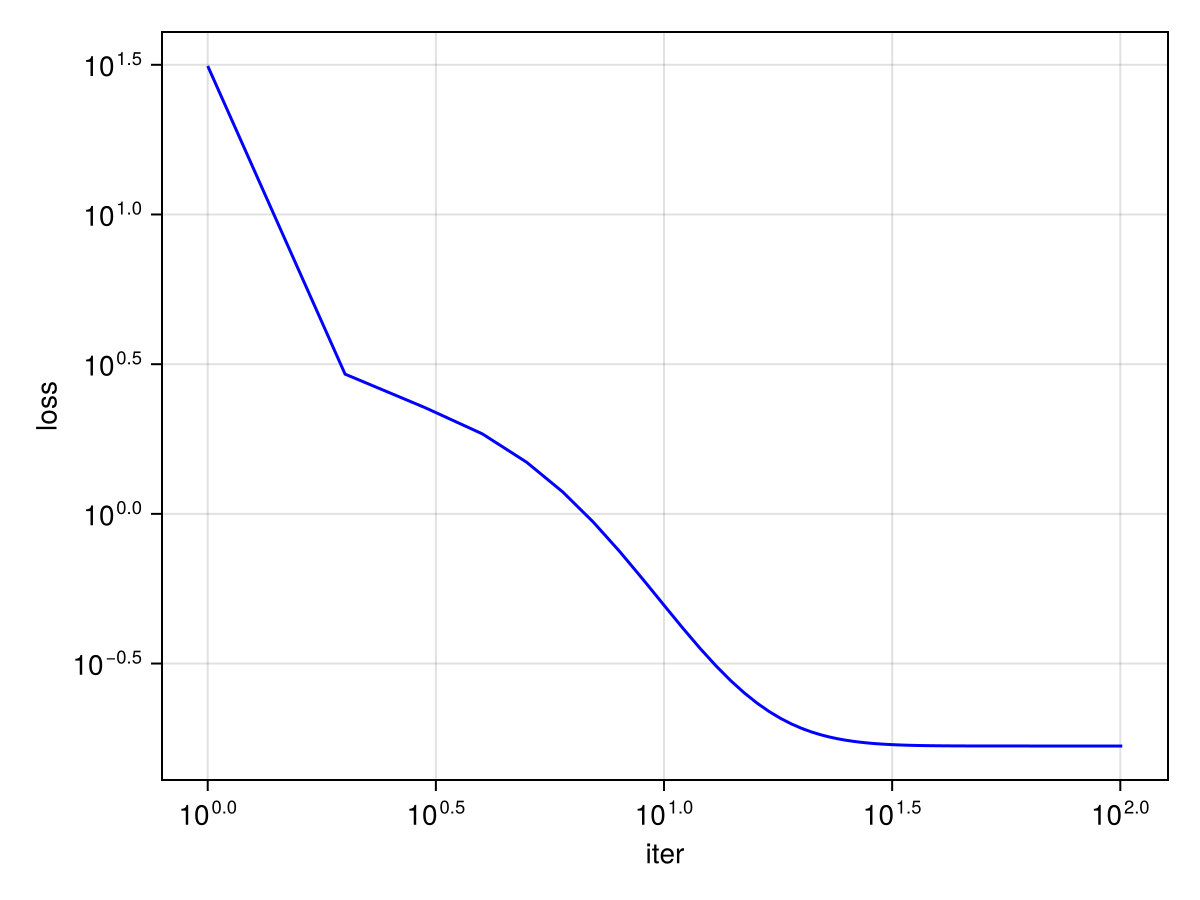

In [40]:
fig = Figure()
ax = Axis(fig[1, 1], xscale=log10,yscale=log10,xlabel = "iter", ylabel = "loss")
lines!(ax,loss_values;color=:blue)
fig

Plot the data and prediction to see if we can get a good fit

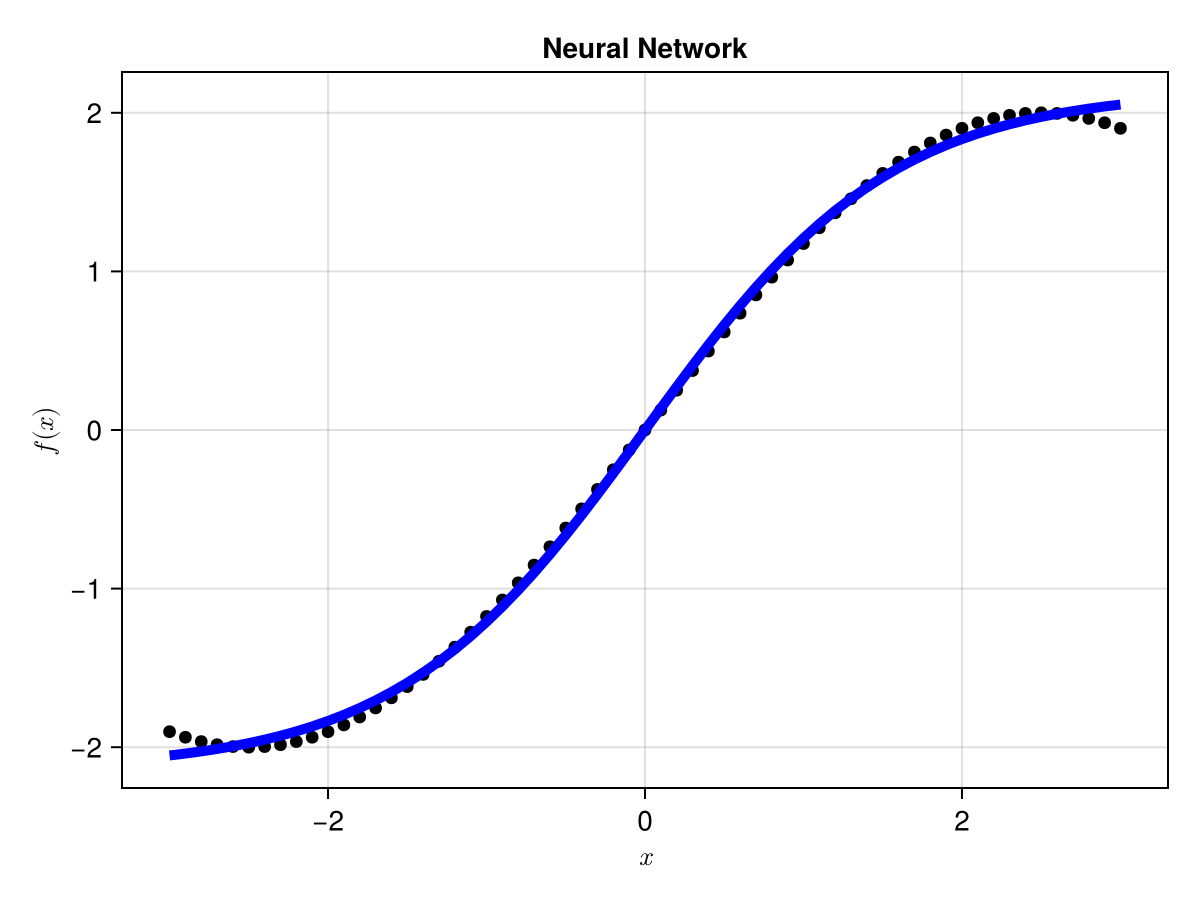

In [41]:
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)",title="Neural Network")
scatter!(ax,xplot,data;color=:black, label="Data")
lines!(ax,xplot,NN03(xplot,W,b);color=:blue,linewidth=5,label="Neural Network")
fig

The plot above now shows that you have a good match with the data.

---
# A bit more about hidden layers

The hidden layers need not have the same number of nodes as the input and output layers.  This will allow for more complex functions to be approximated (but more coefficients to tune!).  For example, a Neural Network with one hidden layer with 3 nodes and input and output layers with one node can be visualised

![Alt text for screen readers](../figures/03p03Fig03.svg)

(the figure above was made using https://alexlenail.me/NN-SVG/)

Mathematically, one can write the expression for this Neural Network as

\begin{align}NN(x;\mathbf{W},\vec{b})&=\begin{bmatrix}W_{21} & W_{22} & W_{23}\end{bmatrix} \left\{ \tanh\left(\begin{bmatrix}W_{11} \\ W_{12} \\ W_{13}\end{bmatrix}x+\begin{Bmatrix}b_{11}\\b_{12}\\b_{13}\end{Bmatrix} \right)\right\}+b_{21} \\


&=\begin{bmatrix}W_{21} & W_{22} & W_{23}\end{bmatrix} \left\{ \tanh\left(\begin{bmatrix}W_{11} x +b_{11}\\ W_{12} x+b_{12}\\ W_{13}x+b_{13}\end{bmatrix} \right)\right\}+b_{21}\\

&=W_{21}\tanh(W_{11}x+b_{11})+W_{22}\tanh(W_{12}x+b_{12})+W_{23}\tanh(W_{13}x+b_{13})+b_{21}

\end{align}




This function has $10$ tunable parameters, $,W_{1}, W_{2}, W_{3},W_{4}, W_{5}, W_{6}, b_1,b_2,b_3$ and $b_4$. In the first line of the expression, I have just grouped all these parameters into a $\theta$.  Neural Network used in real life has many hidden layers with many nodes.  You can imagine how many parameters you need to tune for such a complex Neural network!

---
---
<u>Exercise 04:</u>  You are given that a Neural Network has one input, one output and has a hidden layer with two nodes.  The $\tanh$ activation to connect the input and hidden layer.  There is no activation function from the hidden to the output layer.  Show that this Neural Network can be explictly written down as

$NN(x;\mathbf{W},\vec{b}) =W_{21}\tanh(W_{11}x+b_{11})+W_{22}\tanh(W_{12}x+b_{12})+b_{21}$

---
---



# Multiple Inputs


So far, the functions that have been introduced has one input and one output.  We can define Neural Networks that takes in two inputs, $x_1$ and $x_2$ and 1 output, $f(x_1,x_2)$.  

$f(x_1,x_2)=\tanh\left(\begin{bmatrix}W_{11} & W_{12}\end{bmatrix}\begin{Bmatrix}x_{1} \\ x_{2}\end{Bmatrix}+b_{1} \right)=\tanh\left(W_{11}x_{1}+W_{12}x_2+b_1\right)$

For this Neural Network, there are 3 parameters, $W_{11}$, $W_{12}$ and $b_1$ that you can change in order to change the Neural Network.  This Neural Network can be visualised as

![Alt text for screen readers](../figures/03p03Fig04.svg)


(the figure above was made using https://alexlenail.me/NN-SVG/)

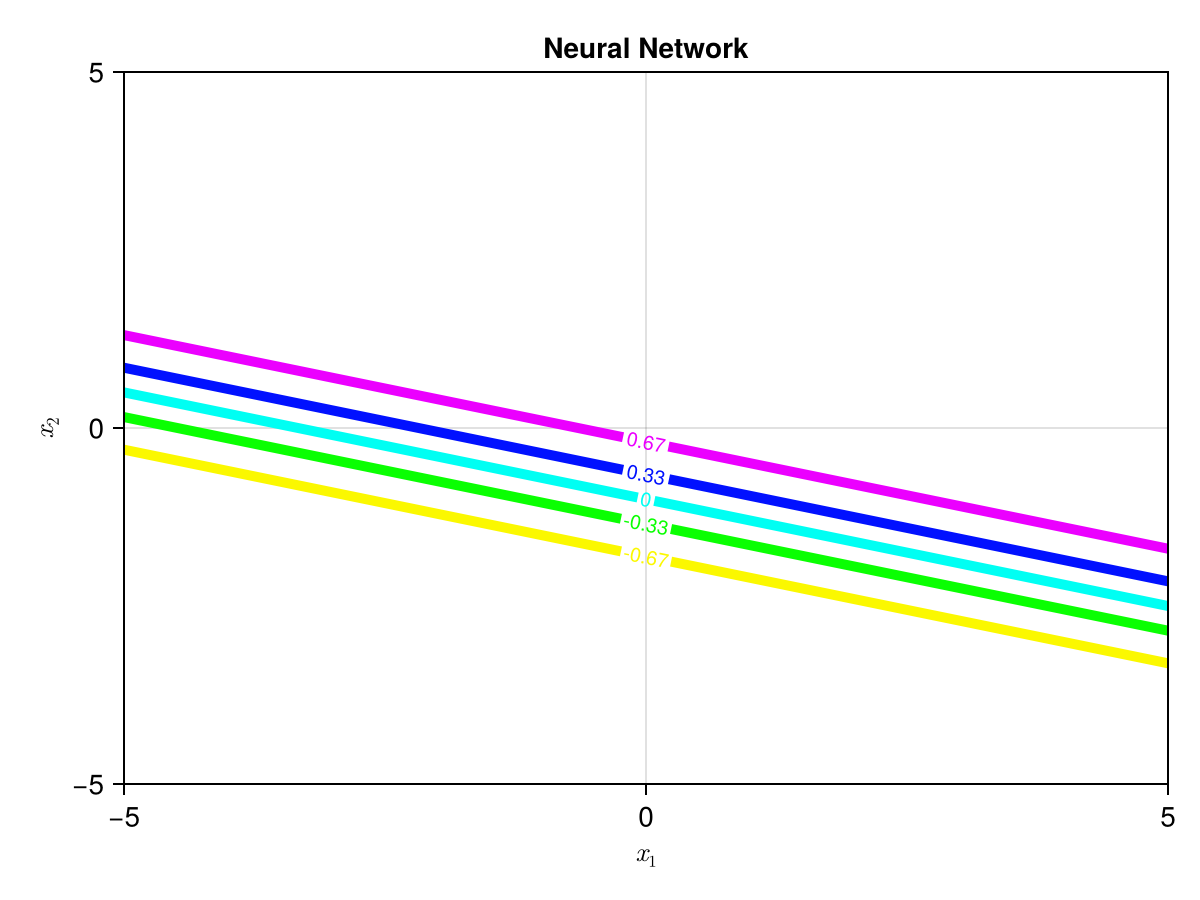

In [32]:
x1range=-5:0.02:5;
x2range=-5:0.02:5;

W=[0.3 1.0]
b=[1]
function f(x)
    return tanh.(W*x+b)
end


x = [[x1i, x2i] for x1i in x1range, x2i in x2range]
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x_1", ylabel = L"x_2",title = "Neural Network",limits=(-5.0,5.0,-5.0,5.0))
contour!(ax,x1range,x2range,only.(f.(x)); labels=true,  colormap=:hsv,linewidth = 5)
fig

<u>Exercise 04:</u> Change $W_1$, $W_2$ and $b_1$ and comment on how they change $NN(x)$.

<u>Exercise 05:</u> How many inputs, outputs and tuneable parameters does the Neural Network below have?

![Alt text for screen readers](../figures/03p03Fig05.svg)